# Using K-Means Clustering to Scenario Reduction

Scenario Reduction and Reassignment of Probabilities: Handling a large number of scenarios (e.g., 1,000) can be computationally intensive. Scenario reduction techniques aim to select a representative subset of scenarios that capture the essential characteristics of the full set.

One common method is k-means clustering, which groups similar scenarios together. After clustering, each cluster can be represented by its centroid (mean scenario), and probabilities can be reassigned based on the proportion of original scenarios in each cluster.

In [4]:
import sys
sys.path.append('../')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import seaborn as sns
from tabulate import tabulate
from helper_funcs import load_csvs_with_substring
import json

plt.style.use("grayscale")

In [5]:
# Load k from config.json
with open("../config.json", "r") as file:
    config = json.load(file)

model_name = str(config.get("model_name"))  # Default to 10 if key is not found
k = int(config.get("cluster", 10))          # Default to 10 if key is not found
out_path = f'C{k}'

In [6]:
# Specify the directory containing your CSV files
directory_path = '../scenarios/da'

# Define the substring to match in filenames
substring_to_match = model_name

# Load the CSV files
scenarios_df, dates = load_csvs_with_substring(directory_path, substring_to_match)
prices_df, _ = load_csvs_with_substring(directory_path, "prices")

Given the characteristics of day-ahead electricity prices, which often exhibit volatility and non-Gaussian behavior, Wasserstein K-Means Clustering is a promising choice. This method accounts for the distributional properties of the data, leading to more meaningful clusters that reflect the underlying variability in electricity prices. While it may be computationally intensive, the benefits in capturing the true nature of the data can outweigh the computational costs.

For a detailed comparison of clustering methods for spatial reduction in energy systems, you may refer to the study by Neumann et al. (2022), which evaluates various clustering approaches in the context of electricity system planning. 
https://energyinformatics.springeropen.com/articles/10.1186/s42162-022-00187-7

Additionally, the paper by Ziel (2020) discusses the use of the energy distance for ensemble and scenario reduction, providing insights into alternative distance metrics for clustering scenarios. 
https://arxiv.org/abs/2005.14670

It's advisable to experiment with multiple methods and evaluate their performance based on your specific dataset and objectives.

In [7]:
def wasserstein_kmeans_clustering(k, prices, scenario_price_df, date):
    """
    Clusters scenarios into k clusters using K-Means and assigns probabilities to each cluster.

    Parameters:
    - k: int, number of clusters to reduce scenarios to.
    - prices: DataFrame, actual prices with a 'DA_price' column.
    - scenario_price_df: DataFrame, scenarios with each row representing a scenario and columns as 'Hour_1', 'Hour_2', ..., 'Hour_24'.
    - date: str, date in 'YYYY-MM-DD' format.

    Returns:
    - representative_scenarios_df: DataFrame, reduced set of representative scenarios.
    - cluster_probabilities: ndarray, probabilities corresponding to each representative scenario.
    """
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scenario_price_df)

    # Assign probabilities to each cluster
    _, counts = np.unique(labels, return_counts=True)
    cluster_probabilities = counts / len(scenario_price_df)

    # Select representative scenarios (closest to cluster centroids)
    representative_scenarios = []
    for i in range(k):
        cluster_indices = np.where(labels == i)[0]
        cluster_scenarios = scenario_price_df.iloc[cluster_indices]
        centroid = kmeans.cluster_centers_[i]
        distances = np.linalg.norm(cluster_scenarios.values - centroid, axis=1)
        closest_index = cluster_indices[np.argmin(distances)]
        representative_scenarios.append(scenario_price_df.iloc[closest_index])

    representative_scenarios_df = pd.DataFrame(representative_scenarios, columns=scenario_price_df.columns)

    # Plotting
    T = 24
    percentiles = [5, 25, 50, 75, 95]
    percentile_values = np.percentile(representative_scenarios_df.values, percentiles, axis=0)
    
    actual_prices = prices['DA_price'].iloc[-T:].values  # Extract last T actual prices

    fig, ax = plt.subplots(figsize=(8, 4))  # Increased figure size

    # Shaded areas for percentile ranges
    ax.fill_between(range(T), percentile_values[0], percentile_values[4], color='black', alpha=0.1, label='5-95% Interval')
    ax.fill_between(range(T), percentile_values[1], percentile_values[3], color='black', alpha=0.2, label='25-75% Interval')

    # Median and mean lines
    ax.plot(range(T), percentile_values[2], color='black', linestyle='--', linewidth=1.5, label='Median Scenario')
    ax.plot(range(T), representative_scenarios_df.mean(axis=0).values, color='dimgray', linestyle='-', linewidth=2, label='Mean of Scenarios')

    # Actual prices
    ax.plot(range(T), actual_prices, color='black', linewidth=2, label='Actual Prices')

    # Labels and Title
    ax.set_ylabel("Price [EUR/MWh]", fontsize=10)
    ax.set_xlabel("Hour", fontsize=10)

    # Fix x-ticks to show every 3 hours
    ax.set_xticks(np.arange(0, T, 3))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, T, 3)], rotation=45)

    # Legend Styling: Place outside the plot to avoid overlap
    ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.05, 1), frameon=True)

    # Grid and axis formatting
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)

    # Adjust layout to prevent clipping
    plt.tight_layout()

    # Save the plot without cutting off the legend
    plt.savefig(f'../images/DA/forecasts/da_reduced_price_scenarios_{date}.png', bbox_inches='tight', dpi=300)

    # Show the figure
    plt.show()

    return representative_scenarios_df, cluster_probabilities

def display_probabilities(cluster_probabilities):
    """
    Display the cluster probabilities in a tabular format.

    Parameters:
    - cluster_probabilities: Array of probabilities corresponding to each representative scenario.
    """
    probability_table = pd.DataFrame({
        f'C {i+1}': [prob] for i, prob in enumerate(cluster_probabilities)
    })
    print(tabulate(probability_table, headers='keys', tablefmt='grid', showindex=False))

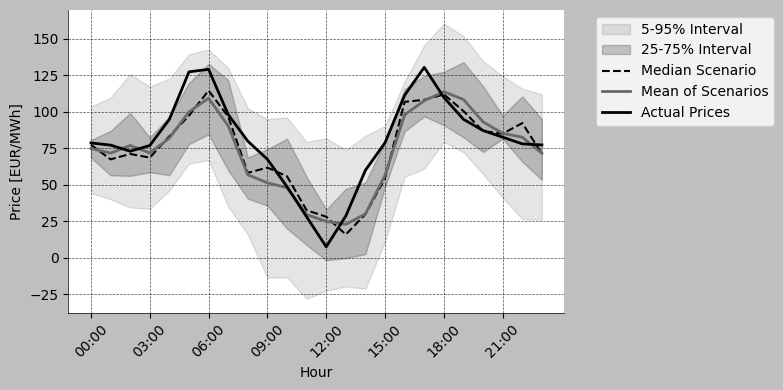

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.107 | 0.087 | 0.091 | 0.086 | 0.138 | 0.096 | 0.071 | 0.148 |  0.06 |  0.116 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


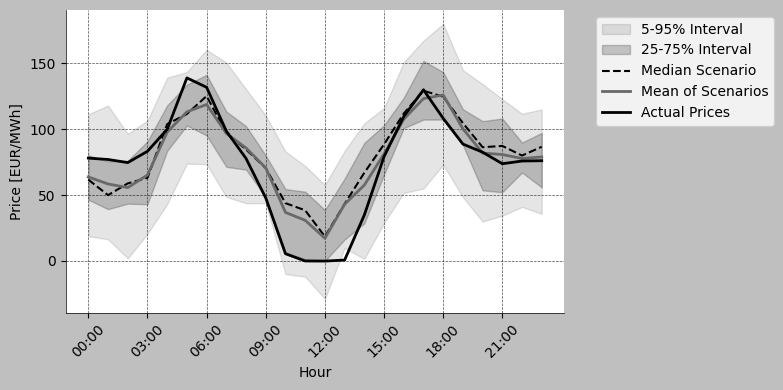

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.093 | 0.093 | 0.104 | 0.127 | 0.121 | 0.085 | 0.126 | 0.131 | 0.056 |  0.064 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


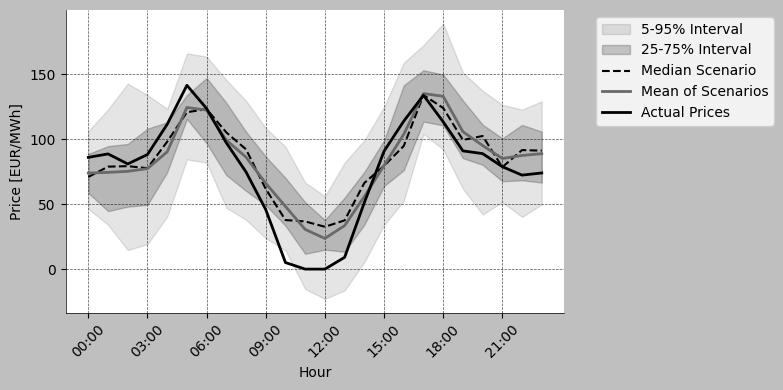

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.108 | 0.119 | 0.059 | 0.094 | 0.086 |  0.05 |  0.09 | 0.122 | 0.137 |  0.135 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


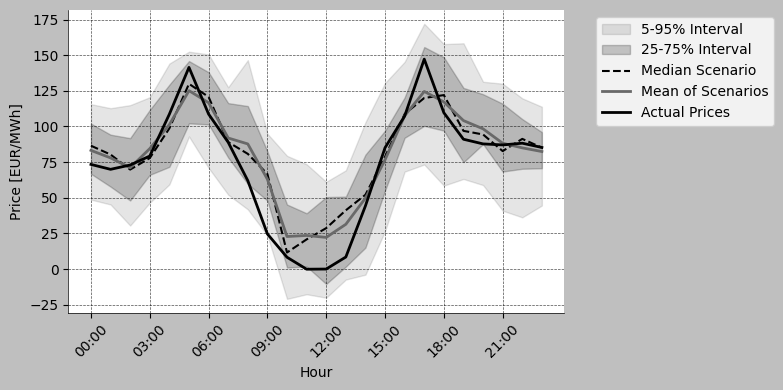

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.076 | 0.129 | 0.096 | 0.089 | 0.055 | 0.108 | 0.126 | 0.124 | 0.115 |  0.082 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


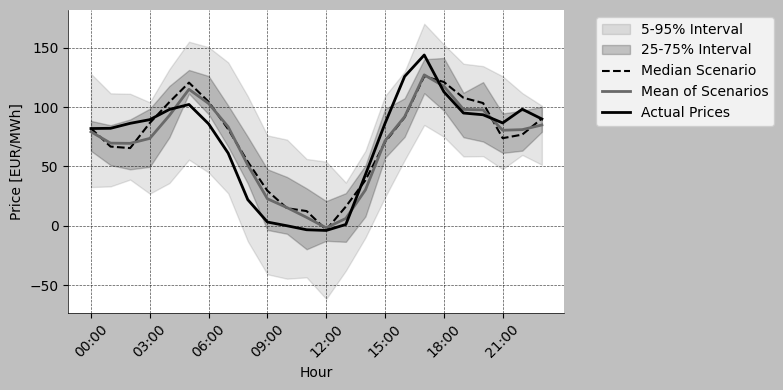

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.101 |  0.12 | 0.102 | 0.061 | 0.105 | 0.162 |   0.1 | 0.094 | 0.074 |  0.081 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


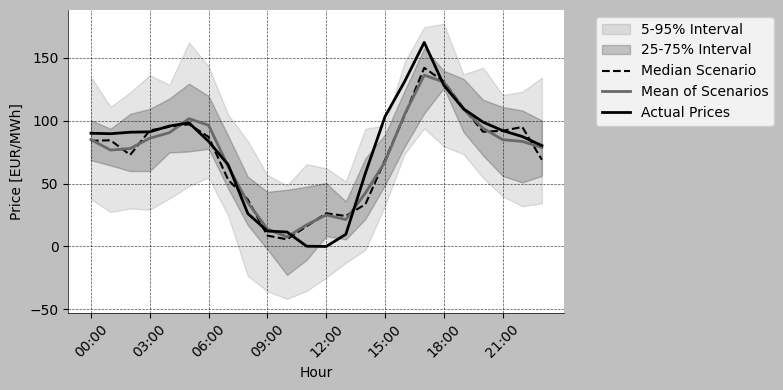

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.141 |  0.13 | 0.103 | 0.114 |  0.05 | 0.049 | 0.108 | 0.108 | 0.075 |  0.122 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


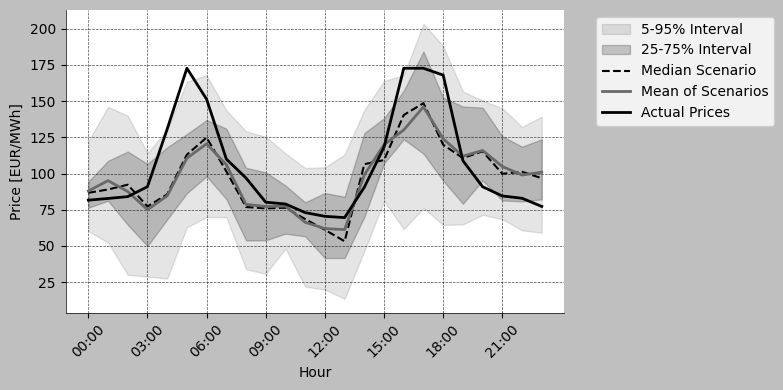

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.062 | 0.123 | 0.133 |  0.11 | 0.116 | 0.136 |  0.07 | 0.079 | 0.063 |  0.108 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


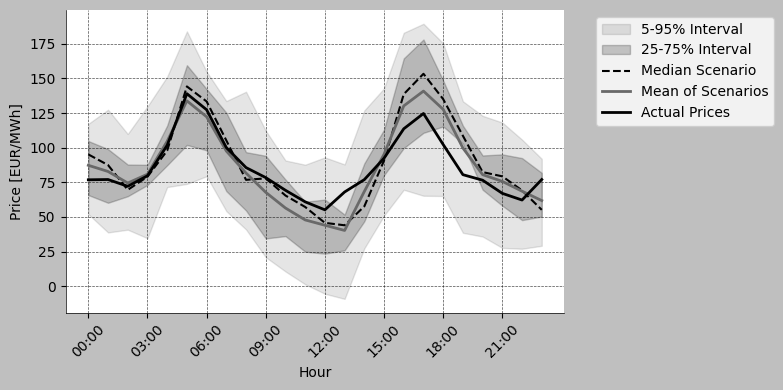

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.085 |  0.11 | 0.118 | 0.095 | 0.063 | 0.107 | 0.088 | 0.113 | 0.085 |  0.136 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


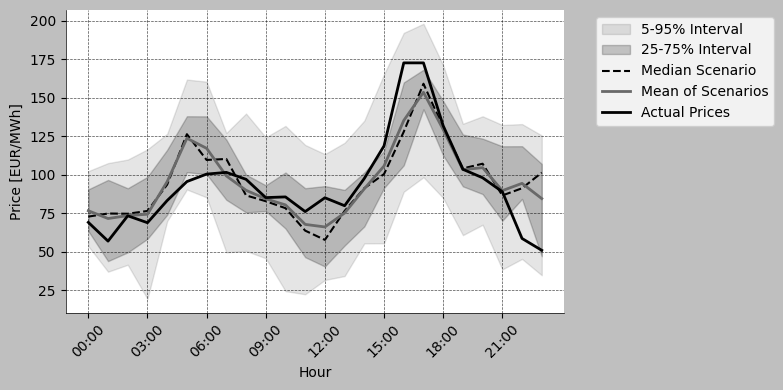

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.067 | 0.115 | 0.134 | 0.104 | 0.063 | 0.085 | 0.141 | 0.107 | 0.089 |  0.095 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


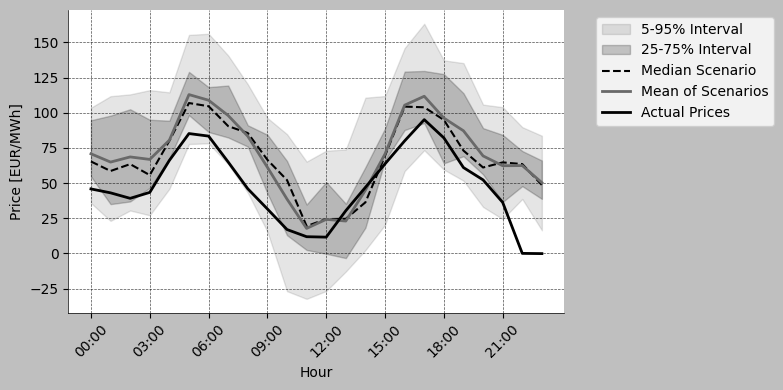

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.139 |  0.11 | 0.065 | 0.104 | 0.075 | 0.093 |  0.13 | 0.091 | 0.112 |  0.081 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


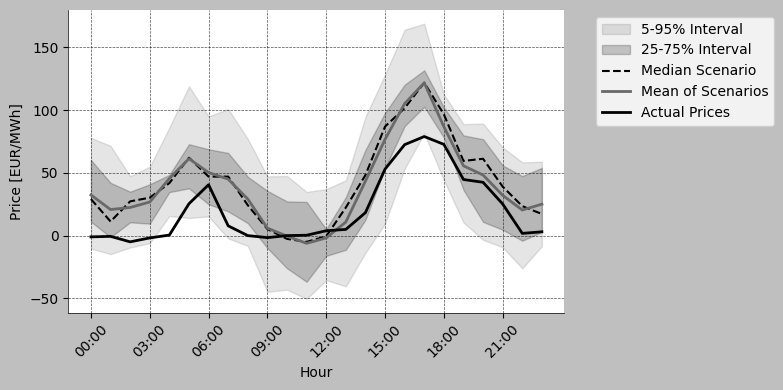

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.085 | 0.099 | 0.073 | 0.112 |  0.14 | 0.073 | 0.115 | 0.091 | 0.095 |  0.117 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


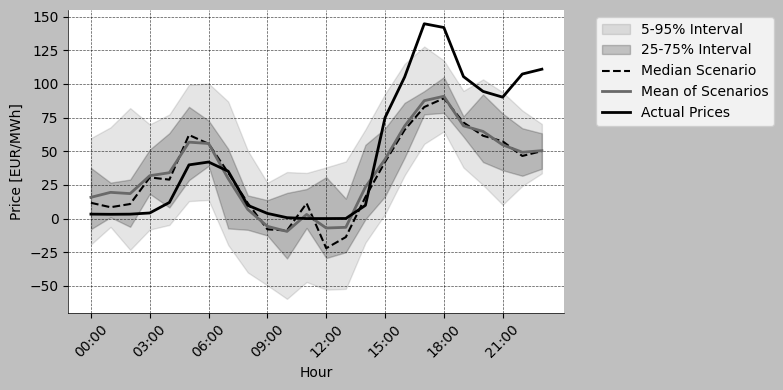

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.133 | 0.099 | 0.115 |  0.08 | 0.098 | 0.078 | 0.116 | 0.104 |  0.12 |  0.057 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


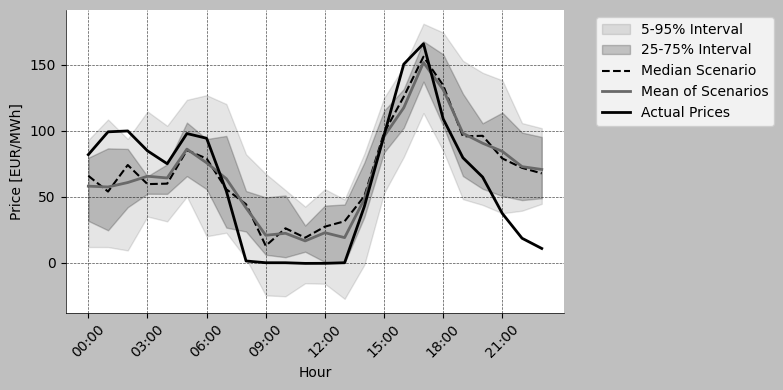

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.125 | 0.086 | 0.072 | 0.055 |  0.14 | 0.122 |  0.09 | 0.115 | 0.085 |   0.11 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


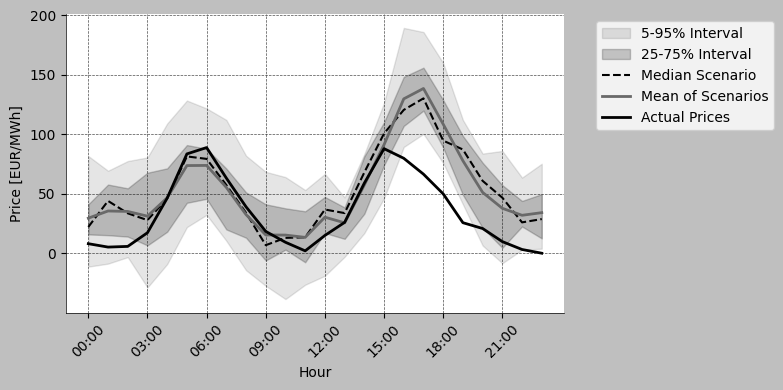

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.151 | 0.072 | 0.097 |  0.11 |  0.09 |  0.12 | 0.136 | 0.073 | 0.082 |  0.069 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


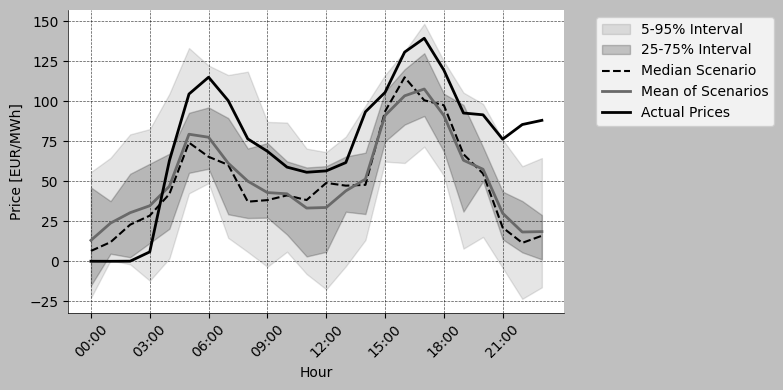

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.071 | 0.111 | 0.124 |  0.08 | 0.111 | 0.129 | 0.094 | 0.093 |  0.13 |  0.057 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


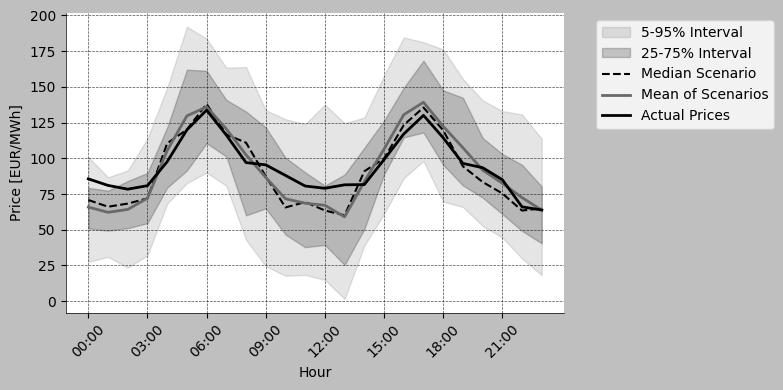

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.095 | 0.113 | 0.086 | 0.094 | 0.072 | 0.127 |  0.11 | 0.138 | 0.072 |  0.093 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


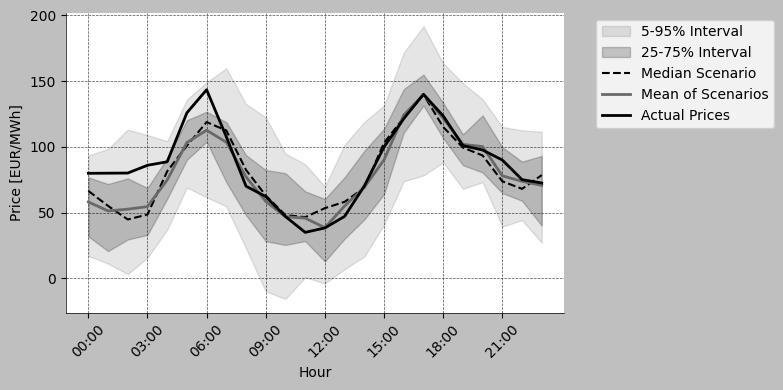

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.064 | 0.077 | 0.094 | 0.107 | 0.137 | 0.166 | 0.065 | 0.066 |  0.08 |  0.144 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


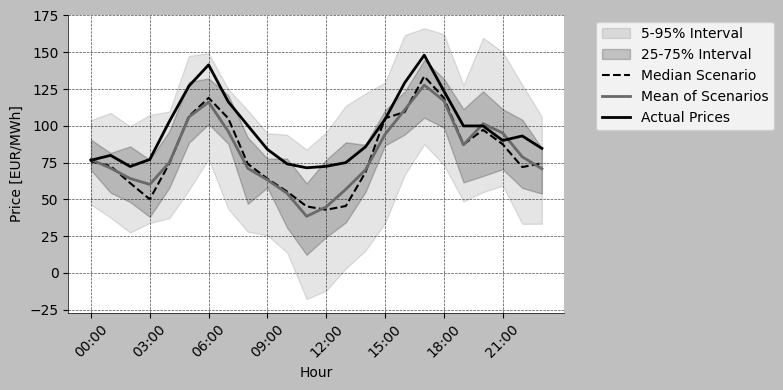

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.123 | 0.058 | 0.115 | 0.078 | 0.108 | 0.081 | 0.091 | 0.124 |   0.1 |  0.122 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


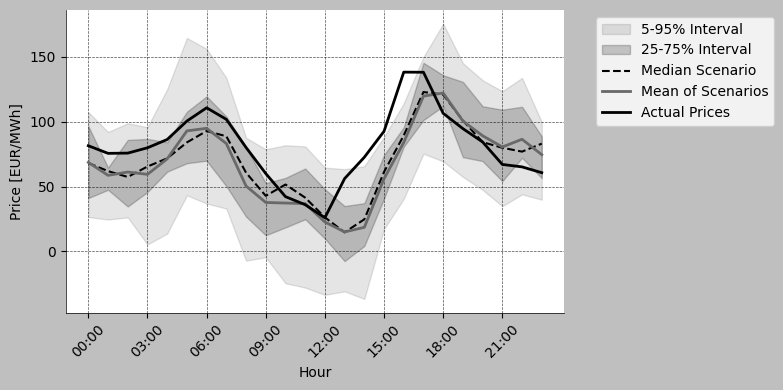

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.103 |  0.08 | 0.101 | 0.148 | 0.098 | 0.143 | 0.068 | 0.085 | 0.066 |  0.108 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


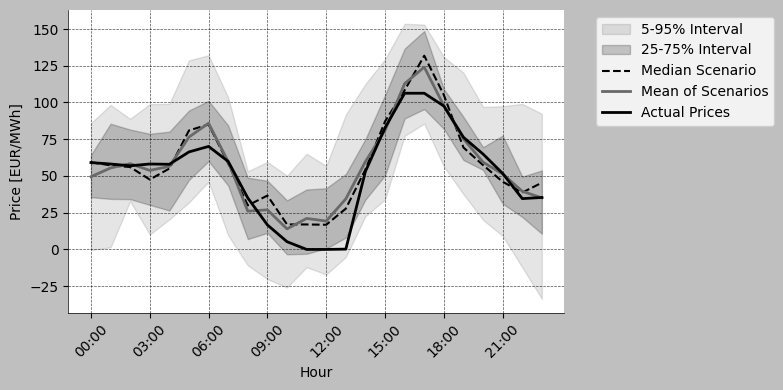

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.088 | 0.074 | 0.114 | 0.106 | 0.109 | 0.077 | 0.083 | 0.128 |  0.08 |  0.141 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


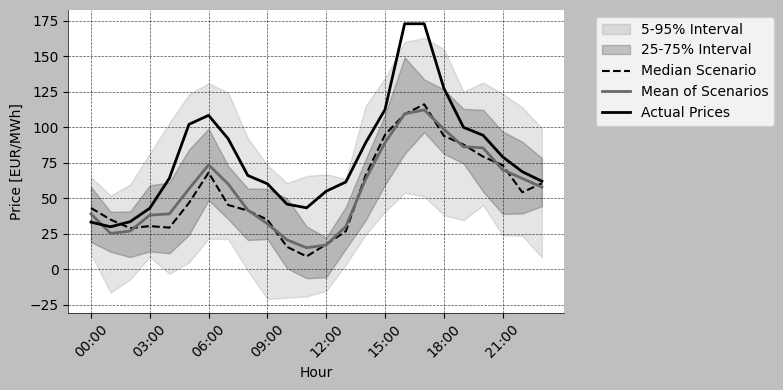

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.116 | 0.104 | 0.106 | 0.114 | 0.061 | 0.082 | 0.096 | 0.094 | 0.131 |  0.096 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


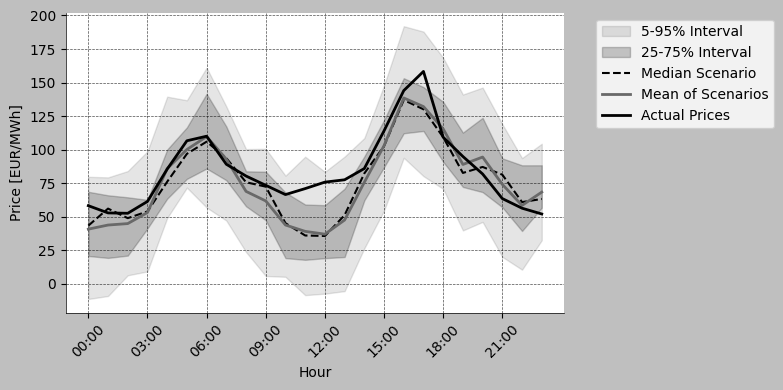

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
|  0.15 | 0.087 | 0.112 | 0.068 | 0.125 | 0.103 | 0.053 | 0.123 | 0.076 |  0.103 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


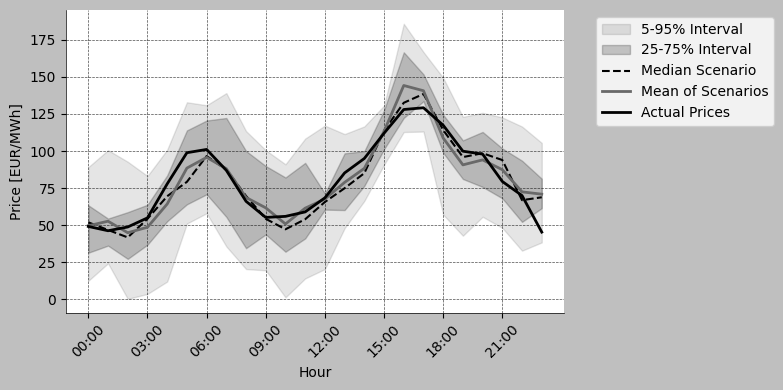

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.091 | 0.114 | 0.105 | 0.096 | 0.136 | 0.073 | 0.119 | 0.117 | 0.073 |  0.076 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


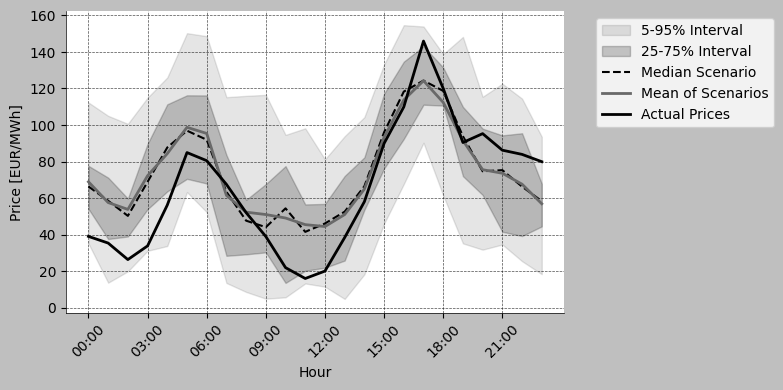

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.105 | 0.104 | 0.089 | 0.078 |  0.06 |  0.17 | 0.091 | 0.113 | 0.095 |  0.095 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


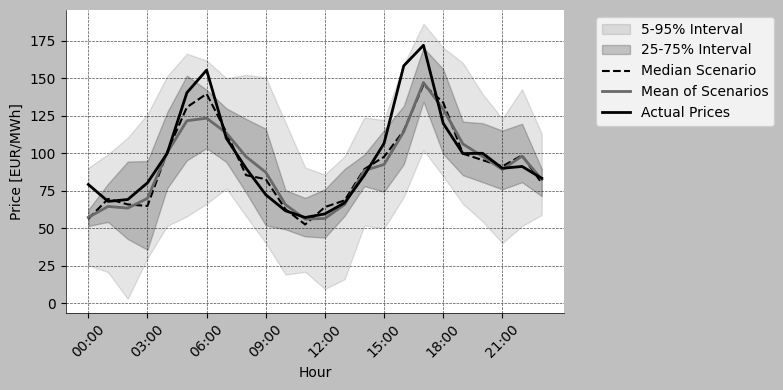

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.046 | 0.112 | 0.163 | 0.111 | 0.127 | 0.117 | 0.105 | 0.081 | 0.094 |  0.044 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


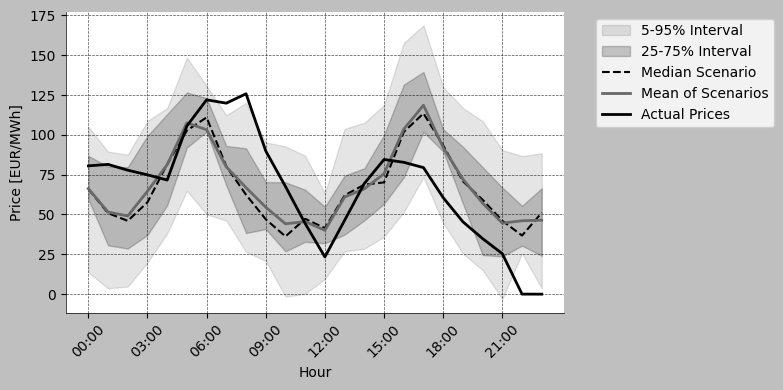

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.108 | 0.097 | 0.094 | 0.067 | 0.127 | 0.079 | 0.111 | 0.079 | 0.136 |  0.102 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


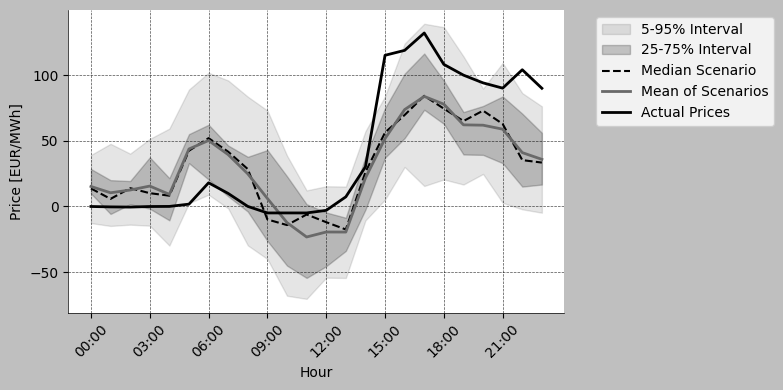

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.089 | 0.117 | 0.077 | 0.123 | 0.125 | 0.076 | 0.109 | 0.066 | 0.106 |  0.112 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


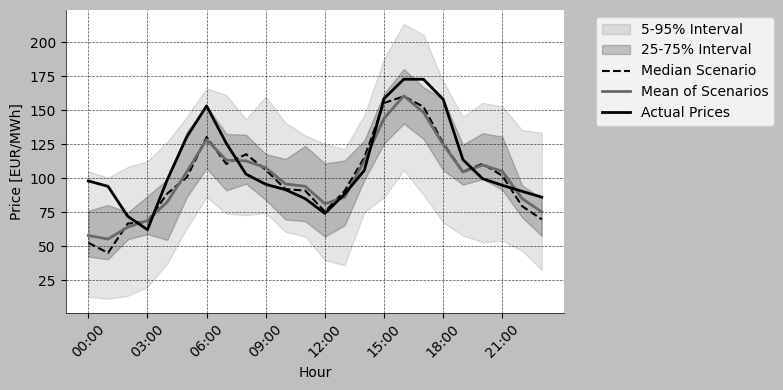

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.084 | 0.053 | 0.115 | 0.097 | 0.117 | 0.122 | 0.054 | 0.129 | 0.136 |  0.093 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


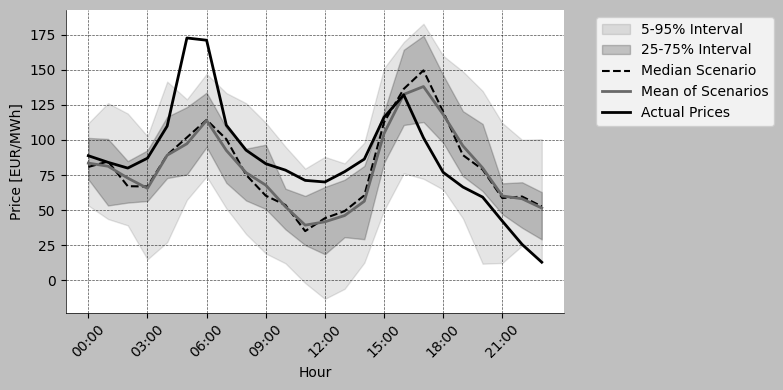

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.141 | 0.111 | 0.103 | 0.093 | 0.099 | 0.085 | 0.111 | 0.106 | 0.103 |  0.048 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


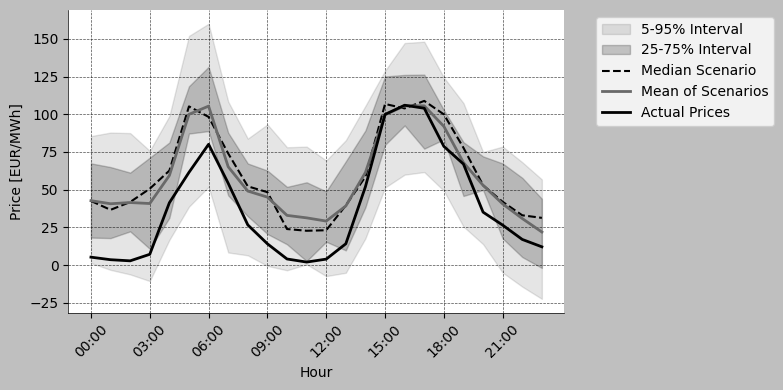

+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+
|   C 1 |   C 2 |   C 3 |   C 4 |   C 5 |   C 6 |   C 7 |   C 8 |   C 9 |   C 10 |
+=======+=======+=======+=======+=======+=======+=======+=======+=======+========+
| 0.103 | 0.131 | 0.142 | 0.079 | 0.089 | 0.115 |   0.1 | 0.104 | 0.076 |  0.061 |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+


In [8]:
# going over each date
for i in range(len(scenarios_df)):
    # reduce scenarios by k-means clustering
    representative_scenarios_df, cluster_probabilities = wasserstein_kmeans_clustering(k, prices_df[i], scenarios_df[i], dates[i])
    representative_scenarios_df.to_csv(f"../reduced_scenarios/{out_path}/da/scenario_{dates[i]}.csv")
    np.savetxt(f"../reduced_scenarios/{out_path}/da/probability_{dates[i]}.txt", cluster_probabilities, fmt="%f")
    # Display probabilities
    display_probabilities(cluster_probabilities)